# Calculate Ranking Metrics

**Metrics được đánh giá:**
- **Precision@K (HitRate@K)**: Tỉ lệ items trong top-K có nằm trong ground truth
- **MRR@K**: Mean Reciprocal Rank - 1/rank của relevant item đầu tiên
- **nDCG@K**: Normalized Discounted Cumulative Gain với graded relevance (0-3)
- **MAP@K**: Mean Average Precision với binary relevance (rel>0)

**Cutoffs:** K = 10, 50

In [8]:
# Import libraries
import pandas as pd
import numpy as np
import pickle
import json
import os
from pathlib import Path
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [9]:
# Setup paths
DATA_PATH = r"E:\DS300-UIT-RecommenderSystem/Finalproject/data/all_recipes_final.csv"
MODELS_PATH = r"E:\DS300-UIT-RecommenderSystem/Finalproject/notebooks/Saved_models"
GROUND_TRUTH_PATH = r"E:\DS300-UIT-RecommenderSystem/Finalproject/notebooks/recommend_and_evaluation/eval_ground_truth.jsonl"
OUTPUT_DIR = r"E:\DS300-UIT-RecommenderSystem/Finalproject/notebooks/recommend_and_evaluation/evaluation_jsonl"


print(f"Data path: {DATA_PATH}")
print(f"Models path: {MODELS_PATH}")
print(f"Ground truth path: {GROUND_TRUTH_PATH}")
print(f"Output directory: {OUTPUT_DIR}")

Data path: E:\DS300-UIT-RecommenderSystem/Finalproject/data/all_recipes_final.csv
Models path: E:\DS300-UIT-RecommenderSystem/Finalproject/notebooks/Saved_models
Ground truth path: E:\DS300-UIT-RecommenderSystem/Finalproject/notebooks/recommend_and_evaluation/eval_ground_truth.jsonl
Output directory: E:\DS300-UIT-RecommenderSystem/Finalproject/notebooks/recommend_and_evaluation/evaluation_jsonl


## 1. Load Ground Truth, Data và Predictions

In [10]:
# Ground truth (json)
ground_truth = []
with open(GROUND_TRUTH_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        ground_truth.append(json.loads(line.strip()))

In [11]:
# query_ids (list)
query_ids = [item['query_id'] for item in ground_truth]
print(f"Loaded {len(query_ids)} query_ids from ground truth")
print(f"First 5 query_ids: {query_ids[:5]}")

Loaded 200 query_ids from ground truth
First 5 query_ids: [49, 84, 140, 191, 246]


In [12]:
# Load data (all recipes - 10k candidate pool)
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df)} recipes")
print(f"Columns: {df.columns.tolist()}")

Loaded 10263 recipes
Columns: ['title', 'type_of_food', 'link', 'description', 'ingredients', 'ingredients_normalized', 'step', 'note', 'num_of_ingredients', 'cook_time', 'num_of_people', 'calories', 'source']


In [13]:
# Add recipe_id column (using index as recipe_id)
df['recipe_id'] = df.index
print(f"Columns: {df.columns.tolist()}")

Columns: ['title', 'type_of_food', 'link', 'description', 'ingredients', 'ingredients_normalized', 'step', 'note', 'num_of_ingredients', 'cook_time', 'num_of_people', 'calories', 'source', 'recipe_id']


In [14]:
# Load ground truth (already loaded earlier, but reload for clarity)
ground_truth_dict = {}
for item in ground_truth:
    query_id = item['query_id']
    # Create mapping: doc_id -> rel score
    relevant_docs = {}
    for doc in item['top_k']:
        relevant_docs[doc['doc_id']] = doc['rel']
    ground_truth_dict[query_id] = relevant_docs

print(f"Loaded ground truth for {len(ground_truth_dict)} queries")
print(f"\nExample ground truth for query {query_ids[0]}:")
print(f"Relevant docs: {ground_truth_dict[query_ids[0]]}")

Loaded ground truth for 200 queries

Example ground truth for query 49:
Relevant docs: {69: 3, 9042: 3, 9221: 3, 8863: 2, 8795: 2, 9651: 2, 9043: 2, 782: 2, 8784: 2, 8911: 2, 9705: 1, 70: 1, 8929: 1, 8805: 1, 9311: 1, 39: 1, 9199: 1, 9141: 1, 1185: 1, 9300: 1}


### 1.1. Load All Prediction Files

In [15]:
# Define all methods to evaluate
method_names = [
    "TFIDF",
    "Ingredient_TFIDF", 
    "Keyword",
    "Hybrid",
    "SBERT_FAISS",
    "Hybrid_TFIDF_SBERT",
    "RARec_Late_Fusion"
]

In [16]:
# Load all prediction files
all_predictions = {}

for method_name in method_names:
    pred_file = os.path.join(OUTPUT_DIR, f"{method_name}_pred.jsonl")
    
    if not os.path.exists(pred_file):
        print(f"  {method_name}: File not found - {pred_file}")
        continue
    
    predictions = []
    with open(pred_file, 'r', encoding='utf-8') as f:
        for line in f:
            predictions.append(json.loads(line.strip()))
    
    all_predictions[method_name] = predictions
    
    # Statistics
    total_docs = sum(len(p['relevant_docs']) for p in predictions)
    avg_docs = total_docs / len(predictions) if predictions else 0
    
    print(f"{method_name:25s}: {len(predictions):3d} queries, {total_docs:6d} total docs ({avg_docs:6.2f} avg)")

TFIDF                    : 200 queries,  20000 total docs (100.00 avg)
Ingredient_TFIDF         : 200 queries,  20000 total docs (100.00 avg)
Keyword                  : 200 queries,  20000 total docs (100.00 avg)
Hybrid                   : 200 queries,  20000 total docs (100.00 avg)
SBERT_FAISS              : 200 queries,  20000 total docs (100.00 avg)
Hybrid_TFIDF_SBERT       : 200 queries,  20000 total docs (100.00 avg)
RARec_Late_Fusion        : 200 queries,  20000 total docs (100.00 avg)


### 1.2. Convert Predictions to Different K Formats

Predictions hiện tại có format: `relevant_docs` (top 100 items)
Cần extract: `top10`, `top50` để tính metrics với different cutoffs

In [17]:
def extract_top_k_items(predictions, k):
    """
    Extract top-K items from predictions
    
    Input: {"query_id": 123, "relevant_docs": [{"doc_id": 456, "score": 0.85}, ...]}
    Output: List of top-K doc_ids and scores
    """
    extracted = []
    
    for pred in predictions:
        # relevant_docs is already sorted by score descending
        top_k_docs = pred['relevant_docs'][:k]
        
        extracted.append({
            'query_id': pred['query_id'],
            'top_items': top_k_docs
        })
    
    return extracted

# No need to convert - we'll use predictions directly and specify K in metric functions
print("Predictions loaded and ready for evaluation at different K values")
print(f"Methods available: {list(all_predictions.keys())}")

Predictions loaded and ready for evaluation at different K values
Methods available: ['TFIDF', 'Ingredient_TFIDF', 'Keyword', 'Hybrid', 'SBERT_FAISS', 'Hybrid_TFIDF_SBERT', 'RARec_Late_Fusion']


## 2. Implement Ranking Metrics Functions

In [18]:
def precision_at_k(predictions, ground_truth_dict, k=10):
    """
    Precision@K (HitRate@K): Tỉ lệ items trong top-K có nằm trong ground truth
    
    Args:
        predictions: List of predictions with 'relevant_docs'
        ground_truth_dict: Dict mapping query_id to {doc_id: rel_score}
        k: Cutoff position
    
    Returns:
        Average Precision@K across all queries
    """
    precisions = []
    
    for pred in predictions:
        query_id = pred['query_id']
        pred_docs = [item['doc_id'] for item in pred['relevant_docs'][:k]]
        
        if query_id not in ground_truth_dict:
            continue
            
        relevant_docs = set(ground_truth_dict[query_id].keys())
        
        # Count hits in top-K
        hits = sum(1 for doc_id in pred_docs if doc_id in relevant_docs)
        precision = hits / k if k > 0 else 0
        precisions.append(precision)
    
    return np.mean(precisions) if precisions else 0.0

In [19]:
def mrr_at_k(predictions, ground_truth_dict, k=10):
    """
    Mean Reciprocal Rank @K: 1/rank của relevant item đầu tiên (trong top K)
    
    Args:
        predictions: List of predictions with 'relevant_docs'
        ground_truth_dict: Dict mapping query_id to {doc_id: rel_score}
        k: Cutoff position
    
    Returns:
        Average MRR@K across all queries
    """
    reciprocal_ranks = []
    
    for pred in predictions:
        query_id = pred['query_id']
        pred_docs = [item['doc_id'] for item in pred['relevant_docs'][:k]]
        
        if query_id not in ground_truth_dict:
            continue
            
        relevant_docs = set(ground_truth_dict[query_id].keys())
        
        # Find first relevant item in top K
        for rank, doc_id in enumerate(pred_docs, 1):
            if doc_id in relevant_docs:
                reciprocal_ranks.append(1.0 / rank)
                break
        else:
            # No relevant item found in top K
            reciprocal_ranks.append(0.0)
    
    return np.mean(reciprocal_ranks) if reciprocal_ranks else 0.0

In [20]:
def ndcg_at_k(predictions, ground_truth_dict, k=10):
    """
    Normalized Discounted Cumulative Gain @K với graded relevance (0-3)
    
    DCG = sum(rel_i / log2(i+1)) for i in 1..k
    IDCG = DCG của ideal ranking (sort by rel desc)
    nDCG = DCG / IDCG
    
    Args:
        predictions: List of predictions with 'relevant_docs'
        ground_truth_dict: Dict mapping query_id to {doc_id: rel_score}
        k: Cutoff position
    
    Returns:
        Average nDCG@K across all queries
    """
    ndcg_scores = []
    
    for pred in predictions:
        query_id = pred['query_id']
        pred_docs = [item['doc_id'] for item in pred['relevant_docs'][:k]]
        
        if query_id not in ground_truth_dict:
            continue
            
        relevant_docs = ground_truth_dict[query_id]  # doc_id -> rel_score (0-3)
        
        # Calculate DCG
        dcg = 0.0
        for rank, doc_id in enumerate(pred_docs, 1):
            rel = relevant_docs.get(doc_id, 0)  # 0 if not in GT
            dcg += rel / np.log2(rank + 1)
        
        # Calculate IDCG (ideal ranking - sort GT by relevance desc)
        ideal_rels = sorted(relevant_docs.values(), reverse=True)[:k]
        idcg = 0.0
        for rank, rel in enumerate(ideal_rels, 1):
            idcg += rel / np.log2(rank + 1)
        
        # nDCG
        if idcg > 0:
            ndcg_scores.append(dcg / idcg)
        else:
            ndcg_scores.append(0.0)
    
    return np.mean(ndcg_scores) if ndcg_scores else 0.0

In [21]:
def map_at_k(predictions, ground_truth_dict, k=10):
    """
    Mean Average Precision @K với binary relevance (rel>0)
    
    AP = (1/min(|rel|, K)) * sum(P@i * rel(i)) for i in 1..K where rel(i)>0
    
    Args:
        predictions: List of predictions with 'relevant_docs'
        ground_truth_dict: Dict mapping query_id to {doc_id: rel_score}
        k: Cutoff position
    
    Returns:
        Average MAP@K across all queries
    """
    ap_scores = []
    
    for pred in predictions:
        query_id = pred['query_id']
        pred_docs = [item['doc_id'] for item in pred['relevant_docs'][:k]]
        
        if query_id not in ground_truth_dict:
            continue
            
        relevant_docs = ground_truth_dict[query_id]  # doc_id -> rel_score
        # Binary relevance: any rel > 0 is relevant
        binary_relevant = {doc_id for doc_id, rel in relevant_docs.items() if rel > 0}
        
        total_relevant = len(binary_relevant)
        
        if total_relevant == 0:
            continue
        
        # Calculate Average Precision within top-K
        num_hits = 0
        sum_precisions = 0.0
        
        for rank, doc_id in enumerate(pred_docs, 1):
            if doc_id in binary_relevant:
                num_hits += 1
                precision_at_rank = num_hits / rank
                sum_precisions += precision_at_rank
        
        # Normalize by min(total_relevant, K) for MAP@K
        ap = sum_precisions / min(total_relevant, k) if total_relevant > 0 else 0.0
        ap_scores.append(ap)
    
    return np.mean(ap_scores) if ap_scores else 0.0

## 3. Calculate Metrics for All Methods

In [22]:
# Calculate metrics for all methods at K=10 and K=50
results = {}

cutoffs = [10, 50]

for method_name in all_predictions.keys():
    print(f"Evaluating {method_name}...")
    print('='*60)
    
    preds = all_predictions[method_name]
    
    # Calculate all metrics at different K values
    metrics = {}
    
    for k in cutoffs:
        metrics[f'Precision@{k}'] = precision_at_k(preds, ground_truth_dict, k=k)
        metrics[f'MRR@{k}'] = mrr_at_k(preds, ground_truth_dict, k=k)
        metrics[f'nDCG@{k}'] = ndcg_at_k(preds, ground_truth_dict, k=k)
        metrics[f'MAP@{k}'] = map_at_k(preds, ground_truth_dict, k=k)
    
    results[method_name] = metrics
    
    # Print metrics
    for metric_name, value in metrics.items():
        print(f"  {metric_name:15s}: {value:.4f}")
    print()

Evaluating TFIDF...
  Precision@10   : 0.5230
  MRR@10         : 0.8589
  nDCG@10        : 0.4749
  MAP@10         : 0.4115
  Precision@50   : 0.2610
  MRR@50         : 0.8589
  nDCG@50        : 0.5916
  MAP@50         : 0.3703

Evaluating Ingredient_TFIDF...
  Precision@10   : 0.3020
  MRR@10         : 0.6206
  nDCG@10        : 0.2727
  MAP@10         : 0.2000
  Precision@50   : 0.1519
  MRR@50         : 0.6242
  nDCG@50        : 0.3517
  MAP@50         : 0.1675

Evaluating Keyword...
  Precision@10   : 0.2550
  MRR@10         : 0.5804
  nDCG@10        : 0.2441
  MAP@10         : 0.1711
  Precision@50   : 0.1268
  MRR@50         : 0.5852
  nDCG@50        : 0.3032
  MAP@50         : 0.1336

Evaluating Hybrid...
  Precision@10   : 0.5425
  MRR@10         : 0.8519
  nDCG@10        : 0.4994
  MAP@10         : 0.4379
  Precision@50   : 0.2573
  MRR@50         : 0.8536
  nDCG@50        : 0.6030
  MAP@50         : 0.3824

Evaluating SBERT_FAISS...
  Precision@10   : 0.4930
  MRR@10         :

## 4. Comparison Table

In [23]:
# Create comparison DataFrame
import pandas as pd

results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

print("\n" + "="*80)
print("COMPARISON TABLE - ALL METHODS")
print("="*80)
print(results_df.to_string())
print("="*80)

# Find best method for each metric
print("\nBest Method per Metric:")
print("-" * 60)
for metric in results_df.columns:
    best_method = results_df[metric].idxmax()
    best_value = results_df[metric].max()
    print(f"{metric:15s}: {best_method:20s} ({best_value:.4f})")
print("-" * 60)


COMPARISON TABLE - ALL METHODS
                    Precision@10  MRR@10  nDCG@10  MAP@10  Precision@50  MRR@50  nDCG@50  MAP@50
TFIDF                     0.5230  0.8589   0.4749  0.4115        0.2610  0.8589   0.5916  0.3703
Ingredient_TFIDF          0.3020  0.6206   0.2727  0.2000        0.1519  0.6242   0.3517  0.1675
Keyword                   0.2550  0.5804   0.2441  0.1711        0.1268  0.5852   0.3032  0.1336
Hybrid                    0.5425  0.8519   0.4994  0.4379        0.2573  0.8536   0.6030  0.3824
SBERT_FAISS               0.4930  0.8753   0.4569  0.3860        0.2458  0.8757   0.5687  0.3431
Hybrid_TFIDF_SBERT        0.6885  0.9596   0.6246  0.6033        0.3251  0.9596   0.7442  0.5472
RARec_Late_Fusion         0.3675  0.6117   0.3158  0.2453        0.2110  0.6155   0.4445  0.2412

Best Method per Metric:
------------------------------------------------------------
Precision@10   : Hybrid_TFIDF_SBERT   (0.6885)
MRR@10         : Hybrid_TFIDF_SBERT   (0.9596)
nDCG@10     

## Step 5: Visualizations

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

### 5.1. Bar Chart - Comparison by Metric (@10)

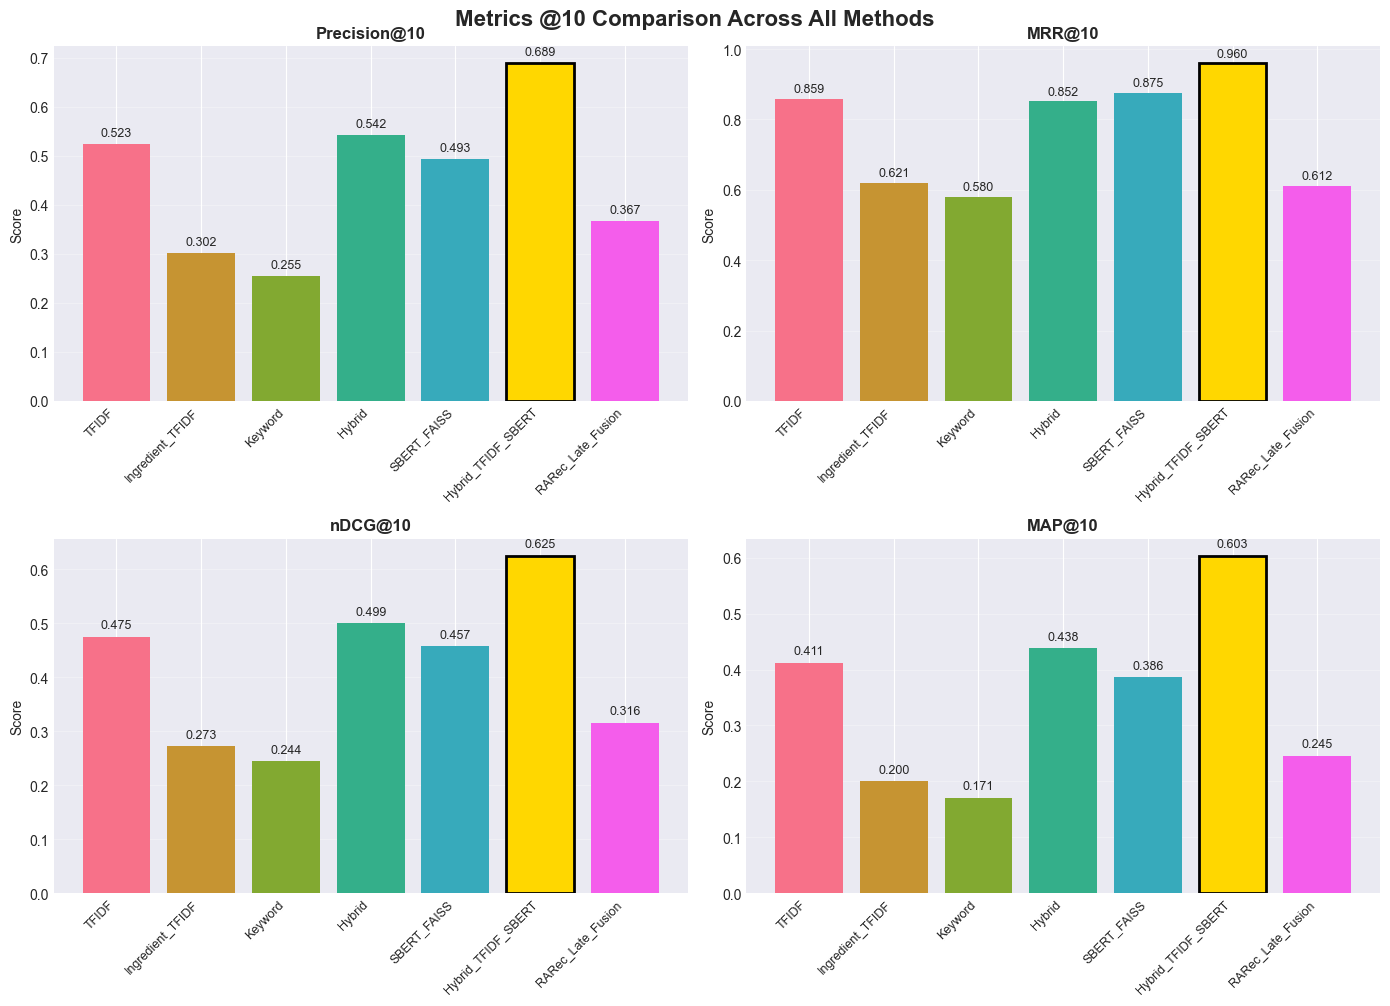

In [25]:
# Bar chart for @10 metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

metrics_at_10 = ['Precision@10', 'MRR@10', 'nDCG@10', 'MAP@10']

for idx, metric in enumerate(metrics_at_10):
    ax = axes[idx]
    
    # Data
    methods = results_df.index.tolist()
    values = results_df[metric].values
    
    # Create bar chart
    bars = ax.bar(range(len(methods)), values, color=sns.color_palette("husl", len(methods)))
    
    # Highlight best method
    best_idx = values.argmax()
    bars[best_idx].set_color('gold')
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2)
    
    # Labels
    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=10)
    ax.set_xticks(range(len(methods)))
    ax.set_xticklabels(methods, rotation=45, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, v in enumerate(values):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.suptitle('Metrics @10 Comparison Across All Methods', fontsize=16, fontweight='bold', y=1.002)
plt.show()

### 5.3. Grouped Bar Chart - @10 vs @50 Comparison

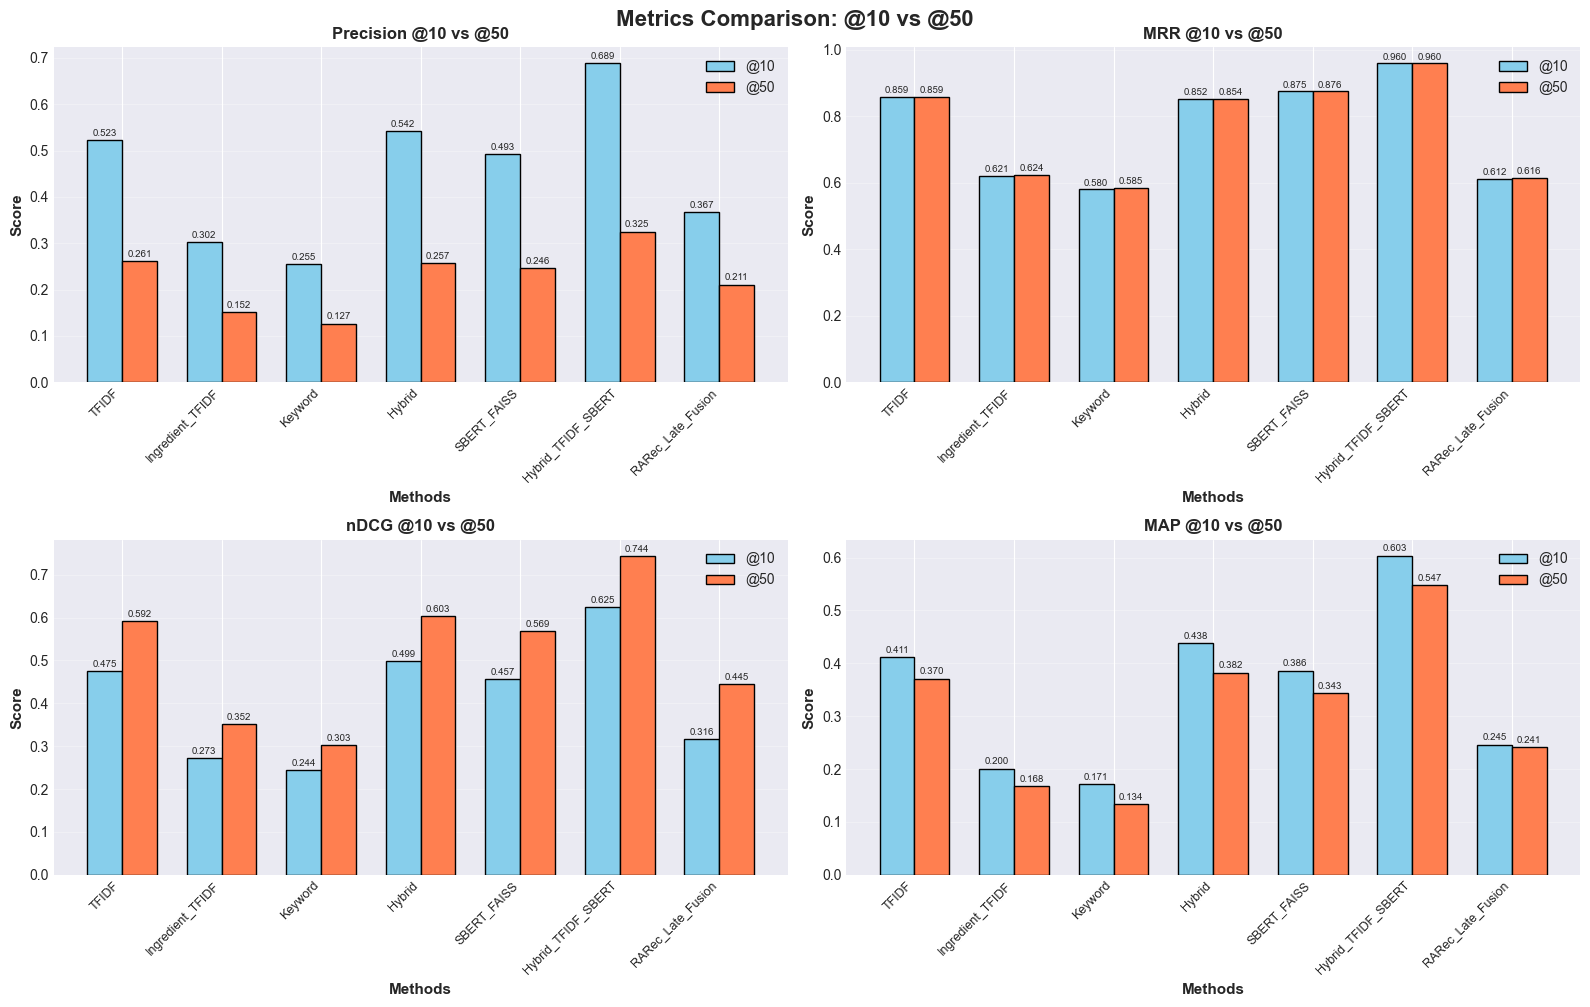

In [26]:
# Grouped bar chart comparing @10 vs @50
metric_types = ['Precision', 'MRR', 'nDCG', 'MAP']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, metric_type in enumerate(metric_types):
    ax = axes[idx]
    
    x = np.arange(len(results_df.index))
    width = 0.35
    
    # Data for @10 and @50
    values_10 = results_df[f'{metric_type}@10'].values
    values_50 = results_df[f'{metric_type}@50'].values
    
    # Create bars
    bars1 = ax.bar(x - width/2, values_10, width, label='@10', color='skyblue', edgecolor='black')
    bars2 = ax.bar(x + width/2, values_50, width, label='@50', color='coral', edgecolor='black')
    
    # Labels
    ax.set_xlabel('Methods', fontsize=11, fontweight='bold')
    ax.set_ylabel('Score', fontsize=11, fontweight='bold')
    ax.set_title(f'{metric_type} @10 vs @50', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(results_df.index, rotation=45, ha='right', fontsize=9)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.suptitle('Metrics Comparison: @10 vs @50', fontsize=16, fontweight='bold', y=1.002)
plt.show()